# Empty drops

In [1]:
library(SingleCellExperiment)
library(data.table)
library(Matrix)
library(EmptyDropsMultiome)
library(ggplot2)
library(dplyr)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

In [2]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/multiome_reanalysis/code"

In [3]:
io = list()
io$home = '/rds/project/rds-SDzz0CATGms/users/bt392/'

io$datadir = sprintf('%s/09_Eomes_invitro_blood/original/', io$home)

In [4]:
opts = list()
opts$samples <- c(
  # first batch
  "rv_eo_deg_day3_5_control",
  "rv_eo_deg_day3_5_dtag",
  "rv_eo_deg_day4_5_control",
  "rv_eo_deg_day4_5_dtag",
  "rv_eo_deg_day4_control",
  "rv_eo_deg_day4_dtag",

  # second batch
  "1A_Eo_DEG_G9_day3",
  "1B_Eo_DEG_G9_day3",
  "2_Eo_DEG_G9_day3_5_dTAG",
  "2_Eo_DEG_G9_day3_5_VC",
  "2_Eo_DEG_G9_day4_dTAG",
  "2_Eo_DEG_G9_day4_VC",
  "2_Eo_DEG_G9_day5_dTAG",
  "2_Eo_DEG_G9_day5_VC"
)

[1] "2_Eo_DEG_G9_day5_dTAG"
number of iterations= 30 
[1] "the mu's are : 18.9877178489837, 358.688880786967, 12251.157588992"
[1] "the sigma's are : 8.33705292380323, 165.043715455847, 10848.665365386"
[1] "the lambdas are : 0.979562555237124, 0.0180023731005913, 0.00243507166228477"
[1] "equil point is 53.7424243365126"
[1] "the lower is : 606.254453970738"
[1] "the rna lower is 606.254453970738"
[1] "the rna barhop is 53.7424243365126"
number of iterations= 12 
[1] "the mu's are : 2.19192529348298, 203.922097286492, 40122.4859714214"
[1] "the sigma's are : 2.50316089058294, 191.626945819951, 55856.8822820474"
[1] "the lambdas are : 0.934486799656634, 0.062256486412347, 0.00325671393101923"
[1] "equil point is 11.9180507816876"
[1] "the lower is : 587.175988926394"


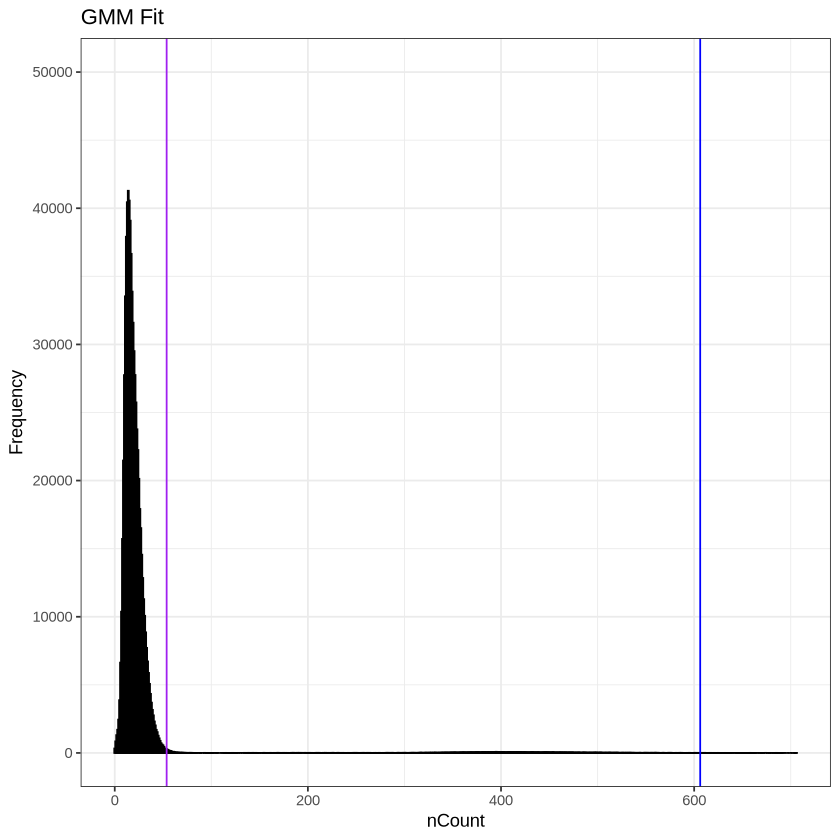

[1] "the atac lower is 587.175988926394"
[1] "the atac barhop is 11.9180507816876"
[1] "Call cells using cellranger-arc"
[1] "finished ordering"
[1] "calculated keep"
[1] "thresholds are 9531.332"         "thresholds are 1838.09499999999"
[1] "the means of the two clusters are: "
  rna_count atac_count
1  1.885295   2.320114
2  4.084948   4.755194
[1]  6.418411 -1.022615
[1] "rownames"   "atac_count" "rna_count"  "excluded"   "is_cell"   
[6] "dup"       
[1] "finished label transfer"
[1] "The number of cells called by k-means is "
[1] "1648 cells"
[1] "the tip has rna count  "
[1] 3.521879
[1] "the tip has atac count  "
[1] 4.124079
[1] "equation_parallel"
[1]  7.289875 -1.022615
[1] "equation"
[1]  6.418411 -1.022615
[1]  7.289875 -1.022615
[1] "lower_line"
[1]  5.614187 -1.022615


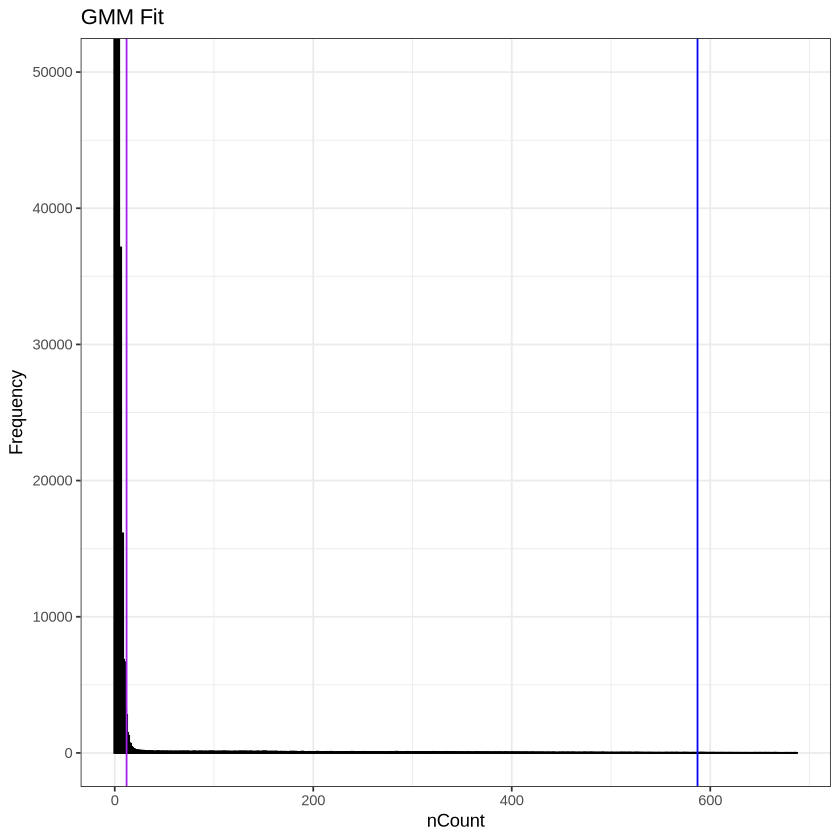

[1] "the number of cells detected is: "
[1] 1745
[1] "saving data"


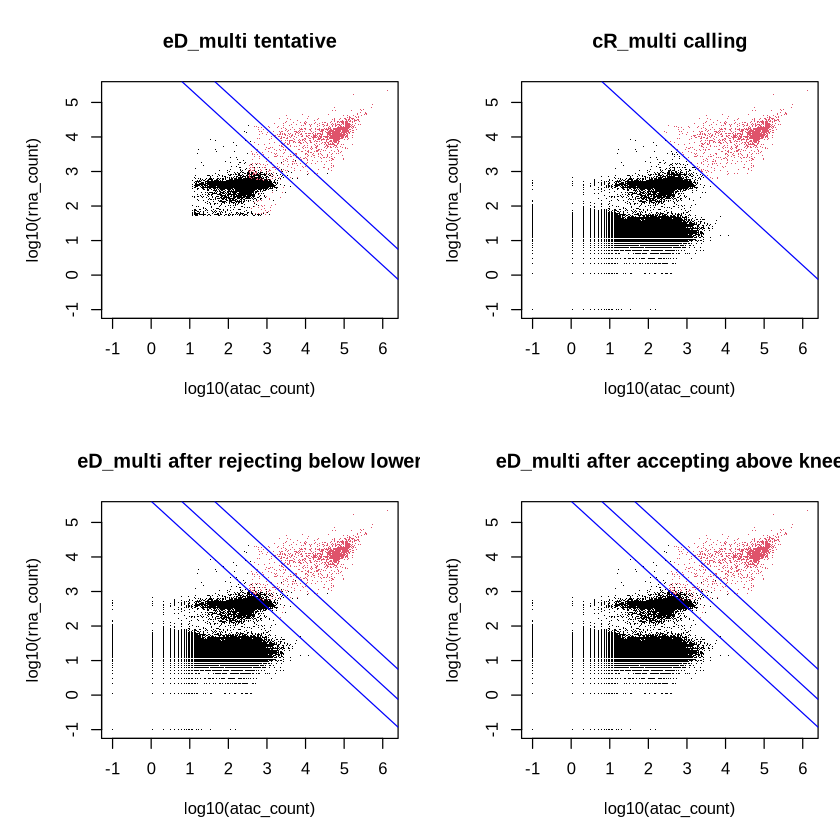

In [8]:
sample = opts$sample[13]
print(sample)
    io$outdir = sprintf('%s/multiome_reanalysis/results/data/%s/', io$home, sample)
    dir.create(io$outdir, showWarnings = F, recursive = T)
    
    data_tmp = sprintf('%s/%s/outs/unfiltered_feature_bc_matrix/', io$datadir, sample)
    barcodes = fread(sprintf('%s/barcodes.tsv.gz', data_tmp), header = F)
    features = fread(sprintf('%s/features.tsv.gz', data_tmp))
    matrix = readMM(gzfile((sprintf('%s/matrix.mtx.gz', data_tmp))))
    
    rownames(matrix) = features$V2
    colnames(matrix) = barcodes$V1
    
    eD.out <- emptydrops_multiome(count_matrix_rna=matrix[grep('Gene Expression', features$V3),], 
                                  count_matrix_atac=matrix[grep('Peaks', features$V3),])
    
    print("the number of cells detected is: ")
    print(sum(eD.out$FDR_multi<0.001 & ! is.na(eD.out$FDR_multi)))
    
    eD.out = as.data.table(eD.out)
    cells_keep = eD.out[FDR_multi<0.001 & ! is.na(FDR_multi), Row.names]
    
    matrix_cells = matrix[, as.character(cells_keep)]
    rownames(matrix_cells) = NULL
    colnames(matrix_cells) = NULL

    print('saving data')
    # writeMM(as(matrix_cells, 'CsparseMatrix'), paste0(io$outdir, 'matrix.mtx'))
    # fwrite(features, paste0(io$outdir, 'features.tsv'), sep = '\t', col.names = F)
    # fwrite(barcodes[V1 %in% cells_keep], paste0(io$outdir, 'barcodes.tsv'), sep = '-', col.names = F)


In [9]:
head(eD.out)

Row.names,Total_RNA,LogProb_RNA,PValue_RNA,Limited_RNA,FDR_RNA,barhop_amb_tent_RNA,Total_chromatin,LogProb_chromatin,PValue_chromatin,Limited_chromatin,FDR_chromatin,barhop_amb_tent_chromatin,PValue_multi,FDR_multi,k_means,above_ambiguous,FDR
<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAACAGCCAAACAACA-1,25,NA,NA,NA,NA,2,0,NA,NA,NA,NA,2,NA,1,0,0,1
AAACAGCCAAACATAG-1,17,NA,NA,NA,NA,2,12,-82.06775,1,0,NA,1,NA,1,0,0,1
AAACAGCCAAACCCTA-1,27,NA,NA,NA,NA,2,0,NA,NA,NA,NA,2,NA,1,0,0,1
AAACAGCCAAACCTAT-1,16,NA,NA,NA,NA,2,0,NA,NA,NA,NA,2,NA,1,0,0,1
AAACAGCCAAACCTTG-1,12,NA,NA,NA,NA,2,4,NA,NA,NA,NA,2,NA,1,0,0,1
AAACAGCCAAACGCGA-1,30,NA,NA,NA,NA,2,0,NA,NA,NA,NA,2,NA,1,0,0,1


In [50]:
meta = eD.out[Row.names %in% cells_keep]

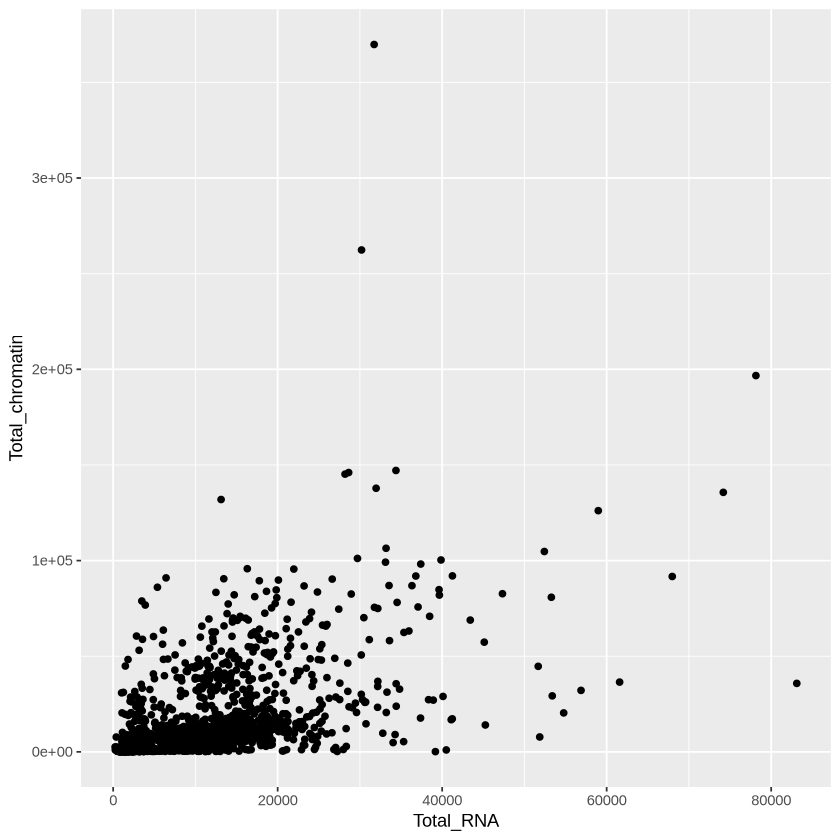

In [52]:
ggplot(meta, aes(Total_RNA, Total_chromatin)) + 
    geom_point()